# Notebook 3 — Model Training & Hyperparameter Tuning

Three models: Logistic Regression (baseline) → Random Forest → XGBoost.
All evaluated on a held-out 20% stratified test set.

In [2]:
import pandas as pd, numpy as np, warnings, joblib
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
df = pd.read_csv('../data/Instagram_Analytics.csv')

def engineer_features(df):
    df = df.copy()
    df['total_interactions']     = df['likes'] + df['comments'] + df['shares'] + df['saves']
    df['save_rate']              = df['saves']   / (df['reach'] + 1)
    df['comment_like_ratio']     = df['comments']/ (df['likes']  + 1)
    df['share_rate']             = df['shares']  / (df['reach']  + 1)
    df['impression_reach_ratio'] = df['impressions'] / (df['reach'] + 1)
    df['virality_score']         = (df['shares'] + df['saves']) / (df['reach'] + 1)
    df['engagement_depth']       = df['comments'] / (df['total_interactions'] + 1)
    df['is_weekend']   = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
    df['is_prime_time']= df['post_hour'].between(18,22).astype(int)
    df['is_morning']   = df['post_hour'].between(6,10).astype(int)
    df['hour_sin']     = np.sin(2*np.pi*df['post_hour']/24)
    df['hour_cos']     = np.cos(2*np.pi*df['post_hour']/24)
    le = LabelEncoder()
    for col in ['media_type','content_category','traffic_source','account_type','day_of_week']:
        df[col+'_enc'] = le.fit_transform(df[col])
    return df

df = engineer_features(df)
df['target'] = df['performance_bucket_label'].map({'low':0,'medium':1,'high':2,'viral':3})

FULL_FEATURES = [
    'follower_count','has_call_to_action','post_hour','caption_length','hashtags_count',
    'engagement_rate','reach','impressions','likes','comments','shares','saves','followers_gained',
    'total_interactions','save_rate','comment_like_ratio','share_rate',
    'impression_reach_ratio','virality_score','engagement_depth',
    'is_weekend','is_prime_time','is_morning','hour_sin','hour_cos',
    'media_type_enc','content_category_enc','traffic_source_enc','account_type_enc','day_of_week_enc'
]
X, y = df[FULL_FEATURES], df['target']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Train: {Xtr.shape}, Test: {Xte.shape}')

Train: (23999, 30), Test: (6000, 30)


## Baseline — Logistic Regression

In [4]:
sc = StandardScaler()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(sc.fit_transform(Xtr), ytr)
lr_pred = lr.predict(sc.transform(Xte))
print(f'Logistic Regression accuracy: {accuracy_score(yte, lr_pred):.4f}')
print(classification_report(yte, lr_pred, target_names=['low','medium','high','viral']))

Logistic Regression accuracy: 0.8708
              precision    recall  f1-score   support

         low       0.92      0.94      0.93      1500
      medium       0.85      0.84      0.85      1500
        high       0.82      0.82      0.82      1500
       viral       0.89      0.88      0.88      1500

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000



## Random Forest — RandomizedSearchCV

Searching over `n_estimators`, `max_depth`, `max_features`.

In [5]:
rf_params = {
    'n_estimators': [200, 300, 400],
    'max_depth':    [12, 15, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(Xtr, ytr)
rf_best = rf_search.best_estimator_
rf_pred = rf_best.predict(Xte)
print(f'Best params: {rf_search.best_params_}')
print(f'Random Forest accuracy: {accuracy_score(yte, rf_pred):.4f}')
print(classification_report(yte, rf_pred, target_names=['low','medium','high','viral']))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'n_estimators': 400, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
Random Forest accuracy: 0.9115
              precision    recall  f1-score   support

         low       0.95      0.94      0.94      1500
      medium       0.89      0.88      0.88      1500
        high       0.89      0.88      0.88      1500
       viral       0.93      0.94      0.94      1500

    accuracy                           0.91      6000
   macro avg       0.91      0.91      0.91      6000
weighted avg       0.91      0.91      0.91      6000



## XGBoost — RandomizedSearchCV

In [6]:
xgb_params = {
    'n_estimators':     [200, 300, 400],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.05, 0.1, 0.15],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42, use_label_encoder=False),
    xgb_params, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(Xtr, ytr)
xgb_best = xgb_search.best_estimator_
xgb_pred = xgb_best.predict(Xte)
print(f'Best params: {xgb_search.best_params_}')
print(f'XGBoost accuracy: {accuracy_score(yte, xgb_pred):.4f}')
print(classification_report(yte, xgb_pred, target_names=['low','medium','high','viral']))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
XGBoost accuracy: 0.9035
              precision    recall  f1-score   support

         low       0.94      0.93      0.94      1500
      medium       0.88      0.87      0.87      1500
        high       0.88      0.87      0.87      1500
       viral       0.92      0.94      0.93      1500

    accuracy                           0.90      6000
   macro avg       0.90      0.90      0.90      6000
weighted avg       0.90      0.90      0.90      6000



## Model comparison

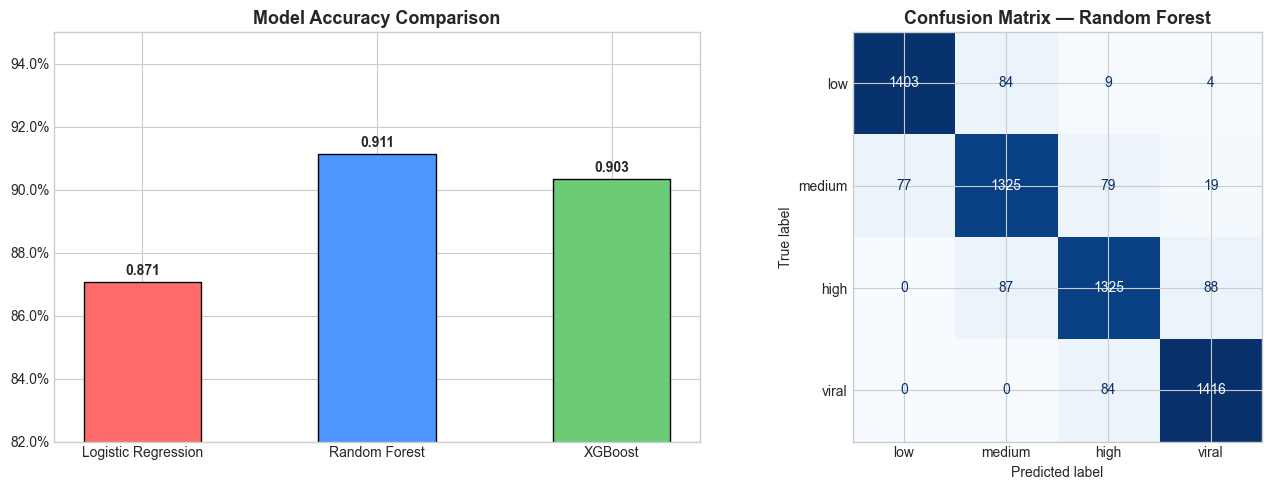

In [7]:
scores = {
    'Logistic Regression': accuracy_score(yte, lr_pred),
    'Random Forest':       accuracy_score(yte, rf_pred),
    'XGBoost':             accuracy_score(yte, xgb_pred)
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(scores.keys(), scores.values(),
                   color=['#FF6B6B','#4D96FF','#6BCB77'], edgecolor='k', width=0.5)
axes[0].set_ylim(0.82, 0.95)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars, scores.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{val:.3f}', ha='center', fontweight='bold')

cm = confusion_matrix(yte, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low','medium','high','viral'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Feature importances — XGBoost

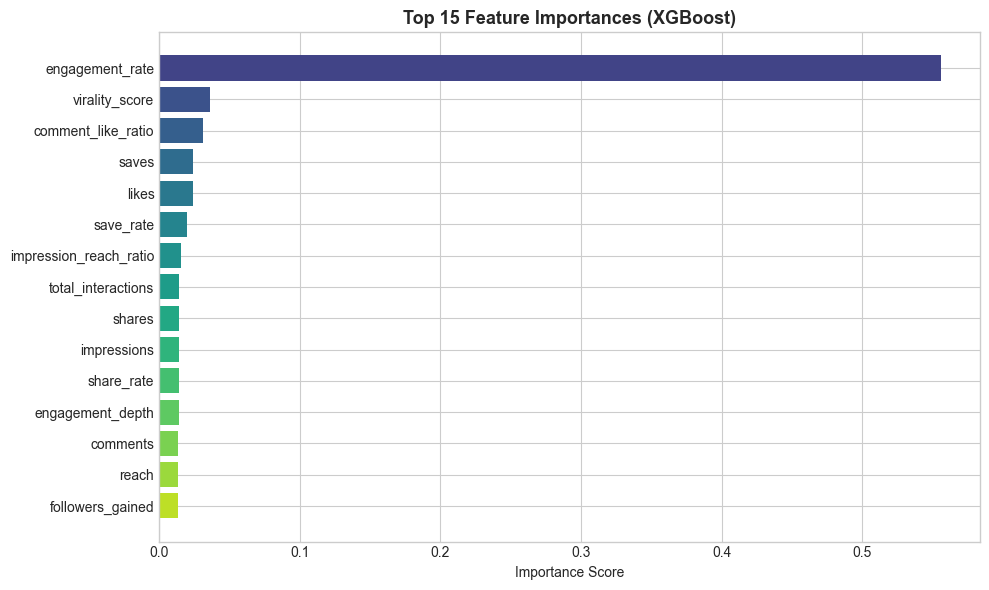

Models saved to ../models/


In [8]:
importances = pd.Series(xgb_best.feature_importances_, index=FULL_FEATURES).sort_values(ascending=False)[:15]
fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(importances)))
ax.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1])
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Save models
joblib.dump(rf_best,  '../models/rf_full.pkl')
joblib.dump(xgb_best, '../models/xgb_full.pkl')
joblib.dump(sc,       '../models/scaler.pkl')
print('Models saved to ../models/')